<a href="https://colab.research.google.com/github/nishchaysingla/Deep_learning_learning/blob/main/sentiment_analysis_simplernn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

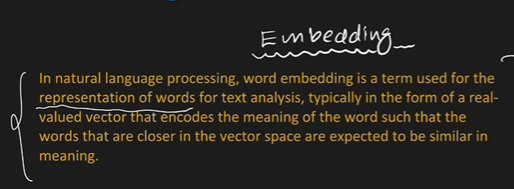

In [1]:
docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()

In [3]:
tokenizer.fit_on_texts(docs)

In [5]:
len(tokenizer.word_index)
## Vocabulary size

17

In [6]:
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[9, 1],
 [1, 1],
 [3, 3, 10],
 [2, 11, 2, 1, 2],
 [12, 13, 4, 5],
 [6, 6],
 [7, 7],
 [8, 8],
 [14, 15, 4, 5],
 [16, 17]]

In [7]:
from keras.utils import pad_sequences
sequences = pad_sequences(sequences,padding='post')
sequences

array([[ 9,  1,  0,  0,  0],
       [ 1,  1,  0,  0,  0],
       [ 3,  3, 10,  0,  0],
       [ 2, 11,  2,  1,  2],
       [12, 13,  4,  5,  0],
       [ 6,  6,  0,  0,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [14, 15,  4,  5,  0],
       [16, 17,  0,  0,  0]], dtype=int32)

In [12]:
from keras.models import Sequential
from keras.layers import Embedding

In [23]:
model = Sequential()
model.add(Embedding(17,output_dim=2,input_length=5))
## Vocabulary length, Embedding Vector size, No. of words/integers in a sentence
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile('adam','accuracy')

In [16]:
pred = model.predict(sequences)
print(pred)
## These are the embeddings for each word of a sentence(length = 5) for all the sentences(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[[ 0.0444365  -0.03060777]
  [-0.0430283  -0.03027371]
  [-0.01675068 -0.01719899]
  [-0.01675068 -0.01719899]
  [-0.01675068 -0.01719899]]

 [[-0.0430283  -0.03027371]
  [-0.0430283  -0.03027371]
  [-0.01675068 -0.01719899]
  [-0.01675068 -0.01719899]
  [-0.01675068 -0.01719899]]

 [[ 0.01669575 -0.01330624]
  [ 0.01669575 -0.01330624]
  [ 0.02795302  0.04674088]
  [-0.01675068 -0.01719899]
  [-0.01675068 -0.01719899]]

 [[ 0.03611651  0.03421483]
  [ 0.03535945 -0.00593802]
  [ 0.03611651  0.03421483]
  [-0.0430283  -0.03027371]
  [ 0.03611651  0.03421483]]

 [[ 0.03917947 -0.00200576]
  [ 0.02058453  0.04661826]
  [-0.02943069 -0.04713694]
  [ 0.02796059  0.00136737]
  [-0.01675068 -0.01719899]]

 [[-0.03077006 -0.01637275]
  [-0.03077006 -0.01637275]
  [-0.01675068 -0.01719899]
  [-0.01675068 -0.01719899]
  [-0.01675068 -0.01719899]]

 [[ 0.04628723 -0.03609165]
  [ 0.04628723 -0.03609165]
  [-0.01675068 -0.01719899]
  [-0.01675068 -0.01719899

In [18]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten

In [19]:
(X_train,y_train),(X_test,y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [20]:
X_train = pad_sequences(X_train,padding='post',maxlen=50)
X_test = pad_sequences(X_test,padding='post',maxlen=50)

In [21]:
X_train.shape

(25000, 50)

In [25]:
model = Sequential()
model.add(Embedding(10000, 2,input_length=50))
model.add(SimpleRNN(32,return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train,epochs=5,validation_data=(X_test,y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - acc: 0.5223 - loss: 0.6902 - val_acc: 0.5744 - val_loss: 0.6669
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.6696 - loss: 0.6007 - val_acc: 0.7632 - val_loss: 0.4957
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.8223 - loss: 0.4040 - val_acc: 0.7633 - val_loss: 0.4891
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.8569 - loss: 0.3426 - val_acc: 0.7795 - val_loss: 0.5015
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.8823 - loss: 0.2940 - val_acc: 0.7670 - val_loss: 0.5225
